### Check the prediction of legnet WTC11 on design and compare with the element results from bcalm 
- read the predictions
- read the bcalm results 
- combine the tables 
- compute the correlation 
- plot the correlation

In [1]:
import ast
import pandas as pd
import os
import yaml

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [2]:
# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'


list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

### Read BCalm variant and element data

In [5]:
variant_map_df_bcalm = pd.read_csv(config['files']['creating']['variants_metadata_bcalm_2025'], sep="\t")
variant_map_df_bcalm = pd.read_csv(config['files']['creating']['NGN2_variants_metadata_bcalm_2025_bbmap_normalized_counts'], sep="\t")
variant_map_df_bcalm

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,0.131536,5.965362e-07,0.190591,cardiac_neuro_cava_random
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000e+00,-0.072051,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000e+00,-0.005889,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47039,C_positive_heart_CAD:ALT_rs7865618_rs7865618,C_positive_heart_CAD:REF_rs7865618,C_positive_heart_CAD:ALT_rs7865618_rs7865618,TATTGATAACAGGGGATGGATTCTTGTGGACAAAAAAATTTAGAAT...,TATTGATAACAGGGGATGGATTCTTGTGGACAAAAAAATTTAGAAT...,[136],True,0.069025,0.177548,1.000000,-0.037515,1.000000e+00,-0.012714,C_positive_heart_CAD
47040,C_positive_heart_CAD:ALT_rs4977757_rs4977757,C_positive_heart_CAD:REF_rs4977757,C_positive_heart_CAD:ALT_rs4977757_rs4977757,CTGATGGGCTTCCCTTTGTGGGTAACCCGACCTTTCTCTCTGGCTG...,CTGATGGGCTTCCCTTTGTGGGTAACCCGACCTTTCTCTCTGGCTG...,[136],True,0.220035,-0.313776,0.042527,-0.087468,7.038279e-05,-0.102879,C_positive_heart_CAD
47041,C_positive_heart_CAD:ALT_rs1537373_rs1537373,C_positive_heart_CAD:REF_rs1537373,C_positive_heart_CAD:ALT_rs1537373_rs1537373,AGAAAACCATACCCACTTTCCCACATATCCCAACTATGACTGGGCA...,AGAAAACCATACCCACTTTCCCACATATCCCAACTATGACTGGGCA...,[136],True,0.341678,0.214433,1.000000,-0.027086,1.000000e+00,0.002929,C_positive_heart_CAD
47042,C_positive_heart_CAD:ALT_rs10811656_rs10811656,C_positive_heart_CAD:REF_rs10811656,C_positive_heart_CAD:ALT_rs10811656_rs10811656,AAATTAAAAGCTTCTAAACTAACAAACAGCCAATTTGTGGAGTGTC...,AAATTAAAAGCTTCTAAACTAACAAACAGCCAATTTGTGGAGTGTC...,[136],True,0.775080,0.089574,1.000000,-0.070829,1.000000e+00,-0.067582,C_positive_heart_CAD


In [6]:
# mpra_80k_metadata_df_bcalm = pd.read_csv(config['files']['creating']['element_metadata_with_bcalm_2025_02'], sep="\t", low_memory=False)
mpra_80k_metadata_df_bcalm = pd.read_csv(config['files']['creating']['undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_scrambled'], sep="\t", low_memory=False)
mpra_80k_metadata_df_bcalm = pd.read_csv(config['files']['creating']['NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_neuro_ctrl'], sep="\t", low_memory=False)
mpra_80k_metadata_df_bcalm = pd.read_csv(config['files']['creating']['NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled'], sep="\t", low_memory=False)

# Apply the safe_eval function to the specified columns
for col in list_columns:
    mpra_80k_metadata_df_bcalm[col] = mpra_80k_metadata_df_bcalm[col].apply(safe_eval)
mpra_80k_metadata_df_bcalm

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,[NC_000001.11:159752292:A:G],[ref],NaN,1.000000e+00,0.002170,True,GC_Mohlke,0.002170,2.425938,0.447914
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,[NC_000001.11:230159168:C:T],[ref],NaN,1.000000e+00,-0.005898,True,GC_Mohlke,-0.005898,2.197536,0.239294
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,"[NC_000001.11:230159168:C:T, NC_000001.11:2301...","[ref, ref]",NaN,1.000000e+00,0.005348,True,GC_Mohlke,0.005348,2.515917,0.530100
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,[NC_000001.11:230159328:TCTTAAAGTGTTCAGCACTCCC:T],[alt],NaN,1.000000e+00,-0.007093,True,GC_Mohlke,-0.007093,2.163688,0.208377
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,[NC_000001.11:230161389:C:T],[ref],NaN,1.332728e-33,0.184521,True,GC_Mohlke,0.184521,7.588730,5.163559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,None,None,NaN,1.000000e+00,-0.007241,True,GC_Glut_Chengyu,-0.007241,2.159500,0.204552
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,None,None,NaN,1.000000e+00,0.030434,True,GC_Glut_Chengyu,0.030434,3.226171,1.178839
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,None,None,NaN,1.614862e-02,0.051942,True,GC_Glut_Chengyu,0.051942,3.835118,1.735046
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,None,None,NaN,9.615387e-01,0.039459,True,GC_Glut_Chengyu,0.039459,3.481679,1.412218


In [7]:
mpra_80k_metadata_df_bcalm['label'].value_counts()

label
cardiac_neuro_cava_random            73940
MK                                    2397
C_positive_heart_AB                    909
GC_Selvarajan                          358
GC_Vista                               256
C_negative_heart_MK                    243
C_negative_neuron_MK                   222
C_negative_neuron_NP                   217
GC_Mendelian_variants                  209
GC_Kircher                             203
C_SLEA                                 200
GC_Cort_Chengyu                        185
C_positive_heart_CAD                    99
C_positive_neuron_NP                    99
C_positive_heart_MK                     97
C_positive_neuron_MK                    96
C_positive_neuron_CD                    94
GC_Glut_Chengyu                         83
GC_DNase_positive_shuffeled             55
GC_Atrial_fib                           45
GC_GABA_Chengyu                         42
GC_DNase_positive                       41
GC_Mohlke                               38
GC_DN

In [115]:
mpra_80k_metadata_df_bcalm.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'],
      dtype='object')

In [116]:
mpra_80k_metadata_df_bcalm

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,[NC_000001.11:159752292:A:G],[ref],NaN,1.000000,-0.020025,True,GC_Mohlke,-0.020025,1.421195,0.115350
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,[NC_000001.11:230159168:C:T],[ref],NaN,1.000000,0.023178,True,GC_Mohlke,0.023178,2.125750,0.837951
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,"[NC_000001.11:230159168:C:T, NC_000001.11:2301...","[ref, ref]",NaN,1.000000,0.030124,True,GC_Mohlke,0.030124,2.239030,0.954133
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,[NC_000001.11:230159328:TCTTAAAGTGTTCAGCACTCCC:T],[alt],NaN,1.000000,0.008197,True,GC_Mohlke,0.008197,1.881436,0.587380
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,[NC_000001.11:230161389:C:T],[ref],NaN,1.000000,-0.004511,True,GC_Mohlke,-0.004511,1.674202,0.374837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,None,None,NaN,1.000000,0.046735,True,GC_Glut_Chengyu,0.046735,2.509905,1.231946
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,None,None,NaN,1.000000,0.084739,True,GC_Glut_Chengyu,0.084739,3.129682,1.867599
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,None,None,NaN,0.338260,0.097477,True,GC_Glut_Chengyu,0.097477,3.337396,2.080633
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,None,None,NaN,0.000374,0.125486,True,GC_Glut_Chengyu,0.125486,3.794178,2.549115


In [117]:
only_bcalm_mpra_80k_metadata = mpra_80k_metadata_df_bcalm.loc[mpra_80k_metadata_df_bcalm['bcalm_data_exists']].copy()
print(only_bcalm_mpra_80k_metadata.shape[0]) # NGN2 data: 72271 # wtc11 data 72897

72897


In [118]:
only_bcalm_mpra_80k_metadata.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'],
      dtype='object')

In [119]:
# only_element_bcalm_metadata_df.columns

### Read metadata regions

In [120]:
# read element and element metadata file and combine them using region id

input_elements_metadata = "metadata_enformer_open_normalized_table_032025"
only_element_bcalm_metadata_df = pd.read_csv(config['files']['creating'][input_elements_metadata], low_memory=False, sep="\t")

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Apply the safe_eval function to the specified columns
for col in list_columns:
    only_element_bcalm_metadata_df[col] = only_element_bcalm_metadata_df[col].apply(safe_eval)

# only_element_bcalm_metadata_df = only_element_bcalm_metadata_df.loc[only_element_bcalm_metadata_df[col_name].str.contains("cardiac_neuro_cava_random")].copy()
only_element_bcalm_metadata_df

only_element_bcalm_metadata_df["region_strand_id"] = only_element_bcalm_metadata_df["region_id"] + "_" + only_element_bcalm_metadata_df[col_strand]

In [121]:
only_element_bcalm_metadata_df

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity_not_normlized,plotting_label_open_screen_neural_progenitor,plotting_label_open_ngn2,plotting_label_open_screen_H9_neural_progenitor,plotting_open_regions_E2G_H9_neural_progenitor,more_active_scrambled,more_active_negative_ctrl,DNase_max,max_col,region_strand_id
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,-0.924899,not open,not open,not open,not E2G,False,False,1.1717,DNASE:BE2C,chr1:2181843-2182113_+
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,0.233557,not open,not open,not open,not E2G,False,True,0.4162,DNASE:spleen male adult (54 years),chr1:2182439-2182709_+
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,-0.203536,not open,not open,not open,not E2G,False,True,0.9793,DNASE:RPMI-7951,chr1:2188389-2188659_+
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636,2192906,+,...,-0.045471,not open,not open,not open,not E2G,False,True,0.3038,DNASE:spleen male adult (54 years),chr1:2192636-2192906_+
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380,2203650,+,...,-1.113070,not open,not open,not open,not E2G,False,False,0.6891,DNASE:RPMI8226,chr1:2203380-2203650_+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24229,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466,154519736,-,...,-0.301431,not open,not open,not open,not E2G,False,True,1.1088,DNASE:BE2C,chrX:154519466-154519736_-
24230,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,0.282614,not open,not open,not open,not E2G,False,True,1.4407,DNASE:SK-MEL-5.1,chrX:154539055-154539325_-
24231,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,0.538105,not open,not open,not open,not E2G,False,True,2.2879,DNASE:BE2C,chrX:154545000-154545270_-
24232,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,-1.000569,not open,not open,not open,not E2G,False,False,5.0170,DNASE:foreskin keratinocyte male newborn.1,chrX:154549802-154550072_-


In [122]:
group_name = "_NGN2"
group_name = "_undiffWTC11"
# update the bcalm values for NGN2:
name_columns_bcalm = ['name', 'bcalm_element_adjusted_p_value', 'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl']
cell_type_bcalm_data_202504 = only_bcalm_mpra_80k_metadata[name_columns_bcalm].copy()
new_column_names = ['name'] + [column + group_name for column in cell_type_bcalm_data_202504.columns if "bcalm" in column]

cell_type_bcalm_data_202504.columns = new_column_names

cell_type_BCalm_element_metadata_info_df = only_element_bcalm_metadata_df.merge(cell_type_bcalm_data_202504, on="name", how="inner").copy()

In [124]:
cell_type_BCalm_element_metadata_info_df.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor', 'open_E2G_neural_progenitor_H9',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized',
       'plotting_label_open_screen_neural_progenitor',
       'plotting_label_open_ngn2',
       'plotting_label_open_screen_H9_neural_progenitor',
       'plotting_open_regions_E2G_H9_neural_progenitor',
       'more_active_scrambled', 'more_active_negative_ctrl', 'DNase_max',
       'max_col', 'region_strand_id',
       'bcalm_element_adjusted_p_

n: 24220
Pearson correlation coefficient: 1.00
P-value: 0.0000


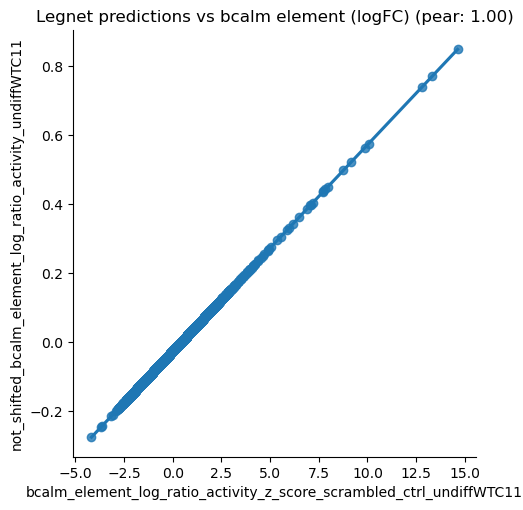

In [ ]:
# # correlation of
# print(f"n: {cell_type_BCalm_element_metadata_info_df.shape[0]}")
# column_name_activity = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl_undiffWTC11"
# column_name_second_activity = "not_shifted_bcalm_element_log_ratio_activity_undiffWTC11"

# # Compute Pearson correlation
# corr_coef, p_value = pearsonr(cell_type_BCalm_element_metadata_info_df[column_name_activity], cell_type_BCalm_element_metadata_info_df[column_name_second_activity])
# print(f'Pearson correlation coefficient: {corr_coef:.2f}')
# print(f'P-value: {p_value:.4f}')

# # Plot using seaborn
# sns.lmplot(x=column_name_activity, y=column_name_second_activity, data=cell_type_BCalm_element_metadata_info_df)
# plt.title(f'Legnet predictions vs bcalm element (logFC) (pear: {corr_coef:.2f})')

# plt.show()

### Read element predictions (Enformer NGN2)

In [22]:
element_enformer_predictions = "/home/kisa/coding/80K_MPRA/modeling/enformer_predictions/element_enformer_predictions/sequences_enformer_DNase_max.tsv.gz"
element_enformer_predictions_df = pd.read_csv(element_enformer_predictions, sep="\t", low_memory=False)
element_enformer_predictions_df

# matchable_header: "~" => ",", "[" => "(" and "]" => ")", "*" => ">"
element_enformer_predictions_df['matchable_header'] = element_enformer_predictions_df['id'].str.replace("~", ",").str.replace("[", "(").str.replace("]", ")").str.replace("*", ">")

In [23]:
mpra_80k_metadata_df_bcalm

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,[NC_000001.11:159752292:A:G],[ref],NaN,1.000000e+00,0.002170,True,GC_Mohlke,0.002170,2.425938,0.447914
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,[NC_000001.11:230159168:C:T],[ref],NaN,1.000000e+00,-0.005898,True,GC_Mohlke,-0.005898,2.197536,0.239294
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,"[NC_000001.11:230159168:C:T, NC_000001.11:2301...","[ref, ref]",NaN,1.000000e+00,0.005348,True,GC_Mohlke,0.005348,2.515917,0.530100
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,[NC_000001.11:230159328:TCTTAAAGTGTTCAGCACTCCC:T],[alt],NaN,1.000000e+00,-0.007093,True,GC_Mohlke,-0.007093,2.163688,0.208377
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,[NC_000001.11:230161389:C:T],[ref],NaN,1.332728e-33,0.184521,True,GC_Mohlke,0.184521,7.588730,5.163559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,None,None,NaN,1.000000e+00,-0.007241,True,GC_Glut_Chengyu,-0.007241,2.159500,0.204552
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,None,None,NaN,1.000000e+00,0.030434,True,GC_Glut_Chengyu,0.030434,3.226171,1.178839
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,None,None,NaN,1.614862e-02,0.051942,True,GC_Glut_Chengyu,0.051942,3.835118,1.735046
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,None,None,NaN,9.615387e-01,0.039459,True,GC_Glut_Chengyu,0.039459,3.481679,1.412218


In [24]:
mpra_80k_metadata_df_bcalm_enformer = mpra_80k_metadata_df_bcalm.merge(element_enformer_predictions_df, left_on="name", right_on="matchable_header", how="left").copy()
mpra_80k_metadata_df_bcalm_enformer


,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,id,DNase_max,max_col,matchable_header
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,0.002170,True,GC_Mohlke,0.002170,2.425938,0.447914,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,4.7823,DNASE:MCF 10A treated with 1 uM tamoxifen for ...,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,-0.005898,True,GC_Mohlke,-0.005898,2.197536,0.239294,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,3.0612,DNASE:A549,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,0.005348,True,GC_Mohlke,0.005348,2.515917,0.530100,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,0.3576,DNASE:SK-MEL-5.1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,-0.007093,True,GC_Mohlke,-0.007093,2.163688,0.208377,NaN,NaN,NaN,NaN
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,0.184521,True,GC_Mohlke,0.184521,7.588730,5.163559,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,1.5944,DNASE:BE2C,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,-0.007241,True,GC_Glut_Chengyu,-0.007241,2.159500,0.204552,NaN,NaN,NaN,NaN
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,0.030434,True,GC_Glut_Chengyu,0.030434,3.226171,1.178839,NaN,NaN,NaN,NaN
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,0.051942,True,GC_Glut_Chengyu,0.051942,3.835118,1.735046,NaN,NaN,NaN,NaN
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,0.039459,True,GC_Glut_Chengyu,0.039459,3.481679,1.412218,NaN,NaN,NaN,NaN


In [26]:
# name not matchable:
not_matchable_name = mpra_80k_metadata_df_bcalm_enformer.loc[mpra_80k_metadata_df_bcalm_enformer['DNase_max'].isna()].copy()
not_matchable_name

# focus on tested sequences results:
mpra_80k_metadata_df_bcalm_enformer_tested = mpra_80k_metadata_df_bcalm_enformer.loc[mpra_80k_metadata_df_bcalm_enformer['name'].str.contains("cardiac_neuro_cava_random")].copy()
mpra_80k_metadata_df_bcalm_enformer_tested

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,id,DNase_max,max_col,matchable_header
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,-0.074506,True,cardiac_neuro_cava_random,-0.074506,0.255056,-1.534950,cardiac_neuro_cava_random:SKI|ENSG00000157933....,1.1717,DNASE:BE2C,cardiac_neuro_cava_random:SKI|ENSG00000157933....
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,0.024747,True,cardiac_neuro_cava_random,0.024747,3.065142,1.031757,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.4162,DNASE:spleen male adult (54 years),cardiac_neuro_cava_random:SKI|ENSG00000157933....
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,...,0.058800,True,cardiac_neuro_cava_random,0.058800,4.029274,1.912386,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.2817,DNASE:RPMI-7951,cardiac_neuro_cava_random:SKI|ENSG00000157933....
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,...,-0.071544,True,cardiac_neuro_cava_random,-0.071544,0.338923,-1.458346,cardiac_neuro_cava_random:SKI|ENSG00000157933....,1.1004,DNASE:BE2C,cardiac_neuro_cava_random:SKI|ENSG00000157933....
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,-0.044408,True,cardiac_neuro_cava_random,-0.044408,1.107215,-0.756596,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.9793,DNASE:RPMI-7951,cardiac_neuro_cava_random:SKI|ENSG00000157933....
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76222,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,...,0.065547,True,cardiac_neuro_cava_random,0.065547,4.220287,2.086855,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,2.4266,DNASE:BE2C,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
76223,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,...,-0.090558,True,cardiac_neuro_cava_random,-0.090558,-0.199415,-1.950059,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,7.2084,DNASE:bronchial epithelial cell,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
76224,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,0.052674,True,cardiac_neuro_cava_random,0.052674,3.855845,1.753977,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,1.7869,DNASE:H7-hESC.1,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
76225,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,0.016824,True,cardiac_neuro_cava_random,0.016824,2.840822,0.826865,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,1.7946,DNASE:H7-hESC.1,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...


In [27]:
mpra_80k_metadata_df_bcalm_enformer_tested = mpra_80k_metadata_df_bcalm_enformer_tested.loc[mpra_80k_metadata_df_bcalm_enformer_tested['bcalm_data_exists']].copy()
mpra_80k_metadata_df_bcalm_enformer_tested

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl,id,DNase_max,max_col,matchable_header
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,...,-0.074506,True,cardiac_neuro_cava_random,-0.074506,0.255056,-1.534950,cardiac_neuro_cava_random:SKI|ENSG00000157933....,1.1717,DNASE:BE2C,cardiac_neuro_cava_random:SKI|ENSG00000157933....
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,...,0.024747,True,cardiac_neuro_cava_random,0.024747,3.065142,1.031757,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.4162,DNASE:spleen male adult (54 years),cardiac_neuro_cava_random:SKI|ENSG00000157933....
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,...,0.058800,True,cardiac_neuro_cava_random,0.058800,4.029274,1.912386,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.2817,DNASE:RPMI-7951,cardiac_neuro_cava_random:SKI|ENSG00000157933....
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,...,-0.071544,True,cardiac_neuro_cava_random,-0.071544,0.338923,-1.458346,cardiac_neuro_cava_random:SKI|ENSG00000157933....,1.1004,DNASE:BE2C,cardiac_neuro_cava_random:SKI|ENSG00000157933....
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,...,-0.044408,True,cardiac_neuro_cava_random,-0.044408,1.107215,-0.756596,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.9793,DNASE:RPMI-7951,cardiac_neuro_cava_random:SKI|ENSG00000157933....
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76222,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,...,0.065547,True,cardiac_neuro_cava_random,0.065547,4.220287,2.086855,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,2.4266,DNASE:BE2C,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
76223,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,...,-0.090558,True,cardiac_neuro_cava_random,-0.090558,-0.199415,-1.950059,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,7.2084,DNASE:bronchial epithelial cell,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
76224,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,0.052674,True,cardiac_neuro_cava_random,0.052674,3.855845,1.753977,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,1.7869,DNASE:H7-hESC.1,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
76225,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,...,0.016824,True,cardiac_neuro_cava_random,0.016824,2.840822,0.826865,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,1.7946,DNASE:H7-hESC.1,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...


In [28]:
# plot the correlation of the enformer predictions (DNase_max) and the bcalm element log ratio activity (measured)
mpra_80k_metadata_df_bcalm_enformer_tested.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl', 'id',
       'DNase_max', 'max_col', 'matchable_header'],
      dtype='object')

In [31]:
mpra_80k_metadata_df_bcalm_enformer_tested_no_alternative = mpra_80k_metadata_df_bcalm_enformer_tested.loc[~mpra_80k_metadata_df_bcalm_enformer_tested['name'].str.contains("cardiac_neuro_cava_random:ALT_")].copy()


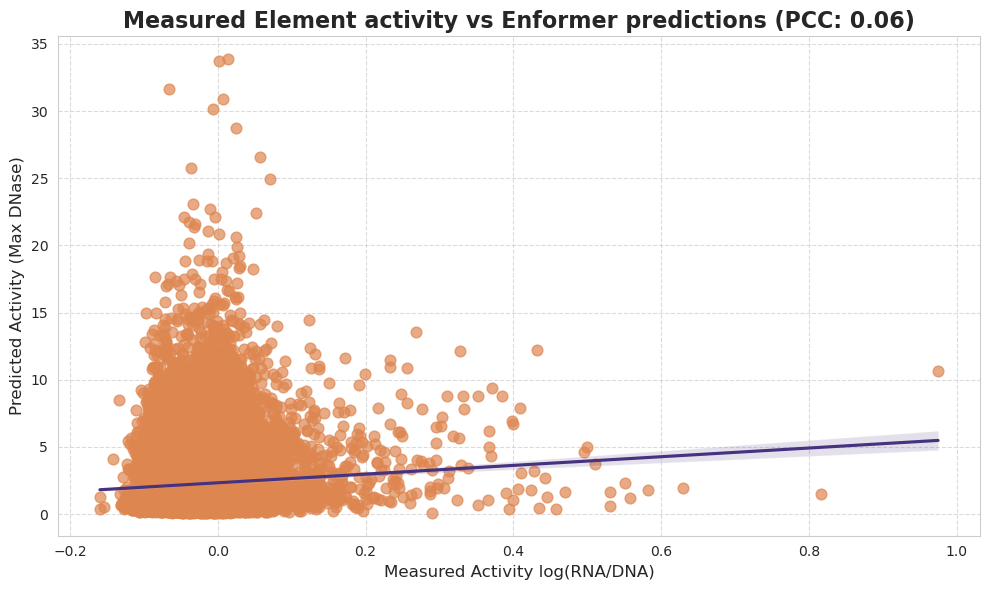

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
# --- 2. Define your columns ---
# Replace 'Feature_X' and 'Target_Y' with your actual column names
col1_name = 'bcalm_element_log_ratio_activity'
col2_name = 'DNase_max'
# col2_name = 'bcalm_element_log_ratio_activity'
# col1_name = 'DNase_max'

# Set a professional style for the plot
sns.set_style("whitegrid") # Options: "darkgrid", "whitegrid", "dark", "white", "ticks"
sns.set_palette("viridis") # Options: "deep", "muted", "bright", "pastel", "dark", "colorblind", "viridis", etc.

plt.figure(figsize=(10, 6)) # Set the figure size for better readability

# Define your custom HEX color for the scatter points
custom_scatter_color = '#DE8650' # A nice shade of blue
# You can find HEX codes easily online, e.g., on HTML color picker sites.

correlation = mpra_80k_metadata_df_bcalm_enformer_tested_no_alternative[col1_name].corr(mpra_80k_metadata_df_bcalm_enformer_tested_no_alternative[col2_name])


# Use seaborn's regplot for a scatter plot with a regression line
ax = sns.regplot(x=col1_name, y=col2_name, data=mpra_80k_metadata_df_bcalm_enformer_tested_no_alternative,
                 scatter_kws={
                     'alpha': 0.7, # Transparency
                     's': 60,      # Size of points
                     'color': custom_scatter_color, # Apply custom HEX color to scatter points
                 },
                 marker='o' # Marker style for points
                )

# --- 4. Customize for Presentation Readiness ---

# Add a title
plt.title(f'Measured Element activity vs Enformer predictions (PCC: {round(correlation,2)})', fontsize=16, fontweight='bold')

# Add labels with clear descriptions
plt.xlabel(f'Measured Activity log(RNA/DNA)', fontsize=12)
plt.ylabel(f'Predicted Activity (Max DNase)', fontsize=12)

# Improve tick label readability
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add a grid for easier reading (seaborn's default might already add it)
ax.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

### Read element predictions (LegNet WTC11)

In [125]:
element_legnet_wtc11_predictions = pd.read_csv(config['files']['creating']['element_predictions_80k_legnet'], sep="\t", header=None, names=[col_name, 'legnet_wtc11_prediction'])

In [126]:
element_legnet_wtc11_predictions.columns

Index(['name', 'legnet_wtc11_prediction'], dtype='object')

In [127]:
element_legnet_wtc11_predictions['label'] = element_legnet_wtc11_predictions[col_name].apply(hf.get_label)

In [128]:
element_legnet_wtc11_predictions['label'].value_counts()

label
cardiac_neuro_cava_random            73940
C_negative_neuron_MK                   222
C_negative_neuron_NP                   217
C_positive_neuron_NP                    99
C_positive_neuron_MK                    96
C_positive_neuron_CD                    94
GC_DNase_positive_shuffeled             55
GC_DNase_positive                       41
GC_DNase_negative_brain_shuffeled       16
GC_DNase_negative_brain                 15
C_negative_heart_MK                     12
C_positive_heart_MK                      4
GC_GABA_Chengyu                          1
Name: count, dtype: int64

In [129]:
# testing_mpra80k_legnet_prediction = only_bcalm_mpra_80k_metadata.merge(element_legnet_wtc11_predictions[['name', 'legnet_wtc11_prediction']], on=col_name, how='inner')
testing_mpra80k_legnet_prediction = cell_type_BCalm_element_metadata_info_df.merge(element_legnet_wtc11_predictions[['name', 'legnet_wtc11_prediction']], on=col_name, how='inner')
testing_mpra80k_legnet_prediction['label'].value_counts()

label
cardiac_neuro_cava_random    24220
Name: count, dtype: int64

In [130]:
tested_mpra80k_legnet_prediction = testing_mpra80k_legnet_prediction.loc[testing_mpra80k_legnet_prediction['label'] == "cardiac_neuro_cava_random"].copy()

In [ ]:
# C_negative_neuron_MK seems to be missing

In [131]:
def get_region_id(row, chr_col="chr", start_col="start", end_col="end", strand_col="strand"):
    return f'{row[chr_col]}:{row[start_col]}-{row[end_col]}_{row[strand_col]}'

tested_mpra80k_legnet_prediction[col_start] = tested_mpra80k_legnet_prediction[col_start].astype(int)
tested_mpra80k_legnet_prediction[col_end] = tested_mpra80k_legnet_prediction[col_end].astype(int)

tested_mpra80k_legnet_prediction['region_strand_id'] = tested_mpra80k_legnet_prediction.apply(lambda row: get_region_id(row, chr_col=col_chr, start_col=col_start, end_col=col_end, strand_col=col_strand), axis=1)
tested_mpra80k_legnet_prediction

,name,sequence,category,class,source,ref,chr,start,end,strand,...,DNase_max,max_col,region_strand_id,bcalm_element_adjusted_p_value_undiffWTC11,bcalm_element_log_ratio_activity_undiffWTC11,bcalm_data_exists_undiffWTC11,not_shifted_bcalm_element_log_ratio_activity_undiffWTC11,bcalm_element_log_ratio_activity_z_score_neg_ctrl_undiffWTC11,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl_undiffWTC11,legnet_wtc11_prediction
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,1.1717,DNASE:BE2C,chr1:2181843-2182113_+,1.0,-0.113830,True,-0.113830,-0.108557,-1.453587,-1.272144
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,0.4162,DNASE:spleen male adult (54 years),chr1:2182439-2182709_+,1.0,0.010062,True,0.010062,1.911857,0.618579,-1.321578
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,0.9793,DNASE:RPMI-7951,chr1:2188389-2188659_+,1.0,-0.005756,True,-0.005756,1.653895,0.354010,-0.990258
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636,2192906,+,...,0.3038,DNASE:spleen male adult (54 years),chr1:2192636-2192906_+,1.0,-0.024935,True,-0.024935,1.341123,0.033226,-1.179183
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380,2203650,+,...,0.6891,DNASE:RPMI8226,chr1:2203380-2203650_+,1.0,-0.152061,True,-0.152061,-0.732015,-2.093014,-1.465978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24215,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466,154519736,-,...,1.1088,DNASE:BE2C,chrX:154519466-154519736_-,1.0,-0.022539,True,-0.022539,1.380206,0.073310,-1.174137
24216,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,1.4407,DNASE:SK-MEL-5.1,chrX:154539055-154539325_-,1.0,0.021838,True,0.021838,2.103896,0.815538,-1.057012
24217,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,2.2879,DNASE:BE2C,chrX:154545000-154545270_-,1.0,0.081223,True,0.081223,3.072344,1.808792,-1.066687
24218,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,5.0170,DNASE:foreskin keratinocyte male newborn.1,chrX:154549802-154550072_-,1.0,-0.099619,True,-0.099619,0.123202,-1.215891,-1.446339


In [132]:
already_known = tested_mpra80k_legnet_prediction.columns

In [133]:
already_known

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor', 'open_E2G_neural_progenitor_H9',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized',
       'plotting_label_open_screen_neural_progenitor',
       'plotting_label_open_ngn2',
       'plotting_label_open_screen_H9_neural_progenitor',
       'plotting_open_regions_E2G_H9_neural_progenitor',
       'more_active_scrambled', 'more_active_negative_ctrl', 'DNase_max',
       'max_col', 'region_strand_id',
       'bcalm_element_adjusted_p_

In [134]:
new_cols = [col for col in only_element_bcalm_metadata_df.columns if not col in already_known]

In [135]:
new_cols
interesting_cols = ['element_vs_negative_control_activity_logFC',
 'element_vs_negative_control_adj_pValue',
 'open_screen_ENCFF221LCO_neural_progenitor',
 'open_NGN2_wtc11_atac',
 'open_H9_neural_progenitor',
 'open_E2G_neural_progenitor_H9',
 'bcalm_element_log_ratio_activity_z_normalized',
 'bcalm_element_log_ratio_activity_not_normlized',
 'plotting_label_open_screen_neural_progenitor',
 'plotting_label_open_ngn2',
 'plotting_label_open_screen_H9_neural_progenitor',
 'plotting_open_regions_E2G_H9_neural_progenitor',
 'more_active_scrambled',
 'more_active_negative_ctrl',
 'DNase_max',
 'max_col', 'region_strand_id']

In [ ]:
# tested_mpra80k_legnet_prediction = tested_mpra80k_legnet_prediction.merge(only_element_bcalm_metadata_df[interesting_cols], on="region_strand_id", how="left").copy()

NameError: name 'interesting_cols' is not defined

In [136]:
tested_mpra80k_legnet_prediction
# tested_mpra80k_legnet_prediction["bcalm_data_exists"].value_counts()

,name,sequence,category,class,source,ref,chr,start,end,strand,...,DNase_max,max_col,region_strand_id,bcalm_element_adjusted_p_value_undiffWTC11,bcalm_element_log_ratio_activity_undiffWTC11,bcalm_data_exists_undiffWTC11,not_shifted_bcalm_element_log_ratio_activity_undiffWTC11,bcalm_element_log_ratio_activity_z_score_neg_ctrl_undiffWTC11,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl_undiffWTC11,legnet_wtc11_prediction
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,1.1717,DNASE:BE2C,chr1:2181843-2182113_+,1.0,-0.113830,True,-0.113830,-0.108557,-1.453587,-1.272144
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,0.4162,DNASE:spleen male adult (54 years),chr1:2182439-2182709_+,1.0,0.010062,True,0.010062,1.911857,0.618579,-1.321578
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,0.9793,DNASE:RPMI-7951,chr1:2188389-2188659_+,1.0,-0.005756,True,-0.005756,1.653895,0.354010,-0.990258
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636,2192906,+,...,0.3038,DNASE:spleen male adult (54 years),chr1:2192636-2192906_+,1.0,-0.024935,True,-0.024935,1.341123,0.033226,-1.179183
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380,2203650,+,...,0.6891,DNASE:RPMI8226,chr1:2203380-2203650_+,1.0,-0.152061,True,-0.152061,-0.732015,-2.093014,-1.465978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24215,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466,154519736,-,...,1.1088,DNASE:BE2C,chrX:154519466-154519736_-,1.0,-0.022539,True,-0.022539,1.380206,0.073310,-1.174137
24216,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,1.4407,DNASE:SK-MEL-5.1,chrX:154539055-154539325_-,1.0,0.021838,True,0.021838,2.103896,0.815538,-1.057012
24217,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,2.2879,DNASE:BE2C,chrX:154545000-154545270_-,1.0,0.081223,True,0.081223,3.072344,1.808792,-1.066687
24218,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,5.0170,DNASE:foreskin keratinocyte male newborn.1,chrX:154549802-154550072_-,1.0,-0.099619,True,-0.099619,0.123202,-1.215891,-1.446339


### correlation of prediction with bcalm values from tested sequences
- with all correlation was 0.18
- with only tested sequences 0.15

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


In [138]:
tested_mpra80k_legnet_prediction.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor', 'open_E2G_neural_progenitor_H9',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized',
       'plotting_label_open_screen_neural_progenitor',
       'plotting_label_open_ngn2',
       'plotting_label_open_screen_H9_neural_progenitor',
       'plotting_open_regions_E2G_H9_neural_progenitor',
       'more_active_scrambled', 'more_active_negative_ctrl', 'DNase_max',
       'max_col', 'region_strand_id',
       'bcalm_element_adjusted_p_

In [46]:
testing_mpra80k_legnet_prediction

,name,sequence,category,class,source,ref,chr,start,end,strand,...,plotting_open_regions_E2G_H9_neural_progenitor,more_active_scrambled,more_active_negative_ctrl,DNase_max,max_col,region_strand_id,bcalm_element_adjusted_p_value_undiffWTC11,bcalm_element_log_ratio_activity_undiffWTC11,bcalm_data_exists_undiffWTC11,legnet_wtc11_prediction
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,not E2G,False,False,1.1717,DNASE:BE2C,chr1:2181843-2182113_+,1.0,-0.113830,True,-1.272144
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,not E2G,False,True,0.4162,DNASE:spleen male adult (54 years),chr1:2182439-2182709_+,1.0,0.010062,True,-1.321578
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,not E2G,False,True,0.9793,DNASE:RPMI-7951,chr1:2188389-2188659_+,1.0,-0.005756,True,-0.990258
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636,2192906,+,...,not E2G,False,True,0.3038,DNASE:spleen male adult (54 years),chr1:2192636-2192906_+,1.0,-0.024935,True,-1.179183
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380,2203650,+,...,not E2G,False,False,0.6891,DNASE:RPMI8226,chr1:2203380-2203650_+,1.0,-0.152061,True,-1.465978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24215,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466,154519736,-,...,not E2G,False,True,1.1088,DNASE:BE2C,chrX:154519466-154519736_-,1.0,-0.022539,True,-1.174137
24216,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,not E2G,False,True,1.4407,DNASE:SK-MEL-5.1,chrX:154539055-154539325_-,1.0,0.021838,True,-1.057012
24217,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,not E2G,False,True,2.2879,DNASE:BE2C,chrX:154545000-154545270_-,1.0,0.081223,True,-1.066687
24218,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,not E2G,False,False,5.0170,DNASE:foreskin keratinocyte male newborn.1,chrX:154549802-154550072_-,1.0,-0.099619,True,-1.446339


Pearson correlation coefficient: 0.15
P-value: 0.0000


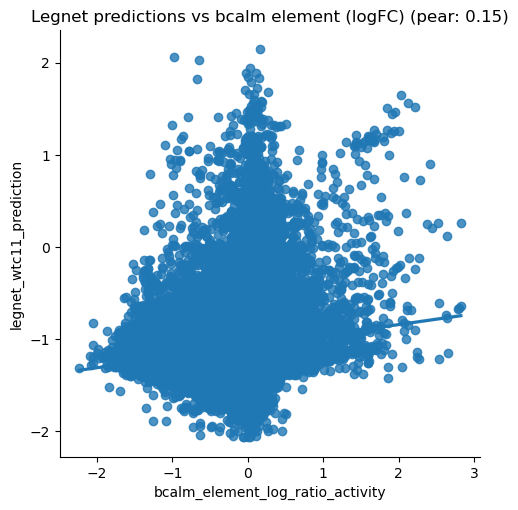

In [62]:
# Compute Pearson correlation
corr_coef, p_value = pearsonr(tested_mpra80k_legnet_prediction['bcalm_element_log_ratio_activity'], tested_mpra80k_legnet_prediction['legnet_wtc11_prediction'])
print(f'Pearson correlation coefficient: {corr_coef:.2f}')
print(f'P-value: {p_value:.4f}')

# Plot using seaborn
sns.lmplot(x='bcalm_element_log_ratio_activity', y='legnet_wtc11_prediction', data=tested_mpra80k_legnet_prediction)
plt.title(f'Legnet predictions vs bcalm element (logFC) (pear: {corr_coef:.2f})')

plt.show()

In [63]:
tested_mpra80k_legnet_prediction.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'legnet_wtc11_prediction', 'region_strand_id',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor', 'open_E2G_neural_progenitor_H9',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized',
       'plotting_label_open_screen_neural_progenitor',
       'plotting_label_open_ngn2',
       'plotting_label_open_screen_H9_neural_progenitor',
       'plotting_open_regions_E2G_H9_neural_progenitor',
       'more_active_scrambled', 'more_active_negative_ctrl', 'DNase_max',
       'max_col'],
      dtype

In [74]:
tested_mpra80k_legnet_prediction["more_active_scrambled"] = (tested_mpra80k_legnet_prediction["bcalm_element_adjusted_p_value"] < 0.1) & (tested_mpra80k_legnet_prediction["bcalm_element_log_ratio_activity"] > 0)

In [69]:
tested_mpra80k_legnet_prediction.loc[tested_mpra80k_legnet_prediction["more_active_scrambled"].isna()]

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized,plotting_label_open_screen_neural_progenitor,plotting_label_open_ngn2,plotting_label_open_screen_H9_neural_progenitor,plotting_open_regions_E2G_H9_neural_progenitor,more_active_scrambled,more_active_negative_ctrl,DNase_max,max_col


In [70]:
tested_mpra80k_legnet_prediction["more_active_scrambled"].isna().sum()

0

Pearson correlation coefficient: 0.28
P-value: 0.0000


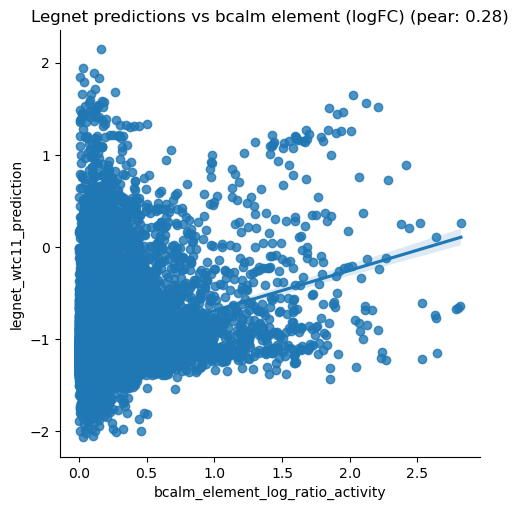

In [75]:
active_scrambled = tested_mpra80k_legnet_prediction.loc[tested_mpra80k_legnet_prediction["more_active_scrambled"]]

# Compute Pearson correlation
corr_coef, p_value = pearsonr(active_scrambled['bcalm_element_log_ratio_activity'], active_scrambled['legnet_wtc11_prediction'])
print(f'Pearson correlation coefficient: {corr_coef:.2f}')
print(f'P-value: {p_value:.4f}')

# Plot using seaborn
sns.lmplot(x='bcalm_element_log_ratio_activity', y='legnet_wtc11_prediction', data=active_scrambled)
plt.title(f'Legnet predictions vs bcalm element (logFC) (pear: {corr_coef:.2f})')

plt.show()

In [77]:
tested_mpra80k_legnet_prediction["more_active_negative_ctrl"] = tested_mpra80k_legnet_prediction["element_vs_negative_control_adj_pValue"] < 0.1

Pearson correlation coefficient: 0.21
P-value: 0.0000


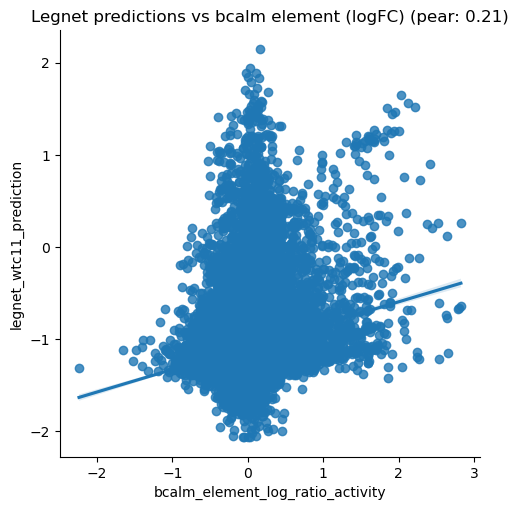

In [80]:
active_negative_control = tested_mpra80k_legnet_prediction.loc[tested_mpra80k_legnet_prediction["more_active_negative_ctrl"]]

# Compute Pearson correlation
corr_coef, p_value = pearsonr(active_negative_control['bcalm_element_log_ratio_activity'], active_negative_control['legnet_wtc11_prediction'])
print(f'Pearson correlation coefficient: {corr_coef:.2f}')
print(f'P-value: {p_value:.4f}')

# Plot using seaborn
sns.lmplot(x='bcalm_element_log_ratio_activity', y='legnet_wtc11_prediction', data=active_negative_control)
plt.title(f'Legnet predictions vs bcalm element (logFC) (pear: {corr_coef:.2f})')

plt.show()

In [89]:
e2g = tested_mpra80k_legnet_prediction.loc[tested_mpra80k_legnet_prediction["open_E2G_neural_progenitor_H9"] == True]

Pearson correlation coefficient: 0.39
P-value: 0.0000


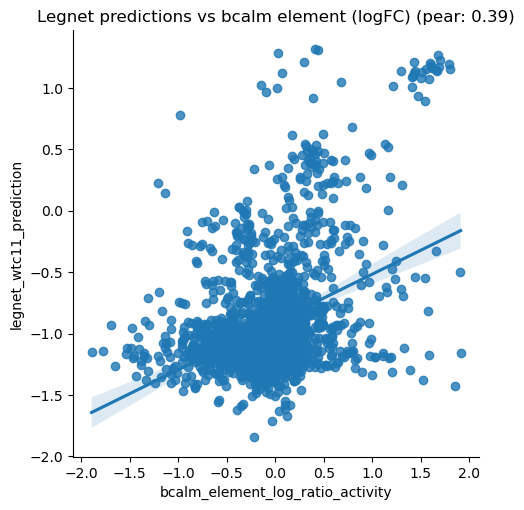

In [90]:

# Compute Pearson correlation
corr_coef, p_value = pearsonr(e2g['bcalm_element_log_ratio_activity'], e2g['legnet_wtc11_prediction'])
print(f'Pearson correlation coefficient: {corr_coef:.2f}')
print(f'P-value: {p_value:.4f}')

# Plot using seaborn
sns.lmplot(x='bcalm_element_log_ratio_activity', y='legnet_wtc11_prediction', data=e2g)
plt.title(f'Legnet predictions vs bcalm element (logFC) (pear: {corr_coef:.2f})')

plt.show()

In [ ]:
e2g = active_negative_control.loc[(active_negative_control["bcalm_element_log_ratio_activity"] > 1) & (active_negative_control["legnet_wtc11_prediction"] > 0.8)]

In [82]:
active_correlation['open_E2G_neural_progenitor_H9'].sum()

25

In [85]:
active_correlation["open_H9_neural_progenitor"].sum()

1

In [86]:
active_correlation["open_NGN2_wtc11_atac"].sum()

0

Pearson correlation coefficient: 0.56
P-value: 0.0003


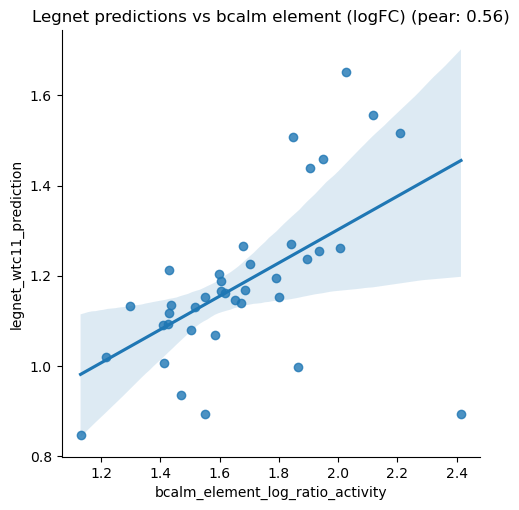

In [81]:
active_correlation = active_negative_control.loc[(active_negative_control["bcalm_element_log_ratio_activity"] > 1) & (active_negative_control["legnet_wtc11_prediction"] > 0.8)]

# Compute Pearson correlation
corr_coef, p_value = pearsonr(active_correlation['bcalm_element_log_ratio_activity'], active_correlation['legnet_wtc11_prediction'])
print(f'Pearson correlation coefficient: {corr_coef:.2f}')
print(f'P-value: {p_value:.4f}')

# Plot using seaborn
sns.lmplot(x='bcalm_element_log_ratio_activity', y='legnet_wtc11_prediction', data=active_correlation)
plt.title(f'Legnet predictions vs bcalm element (logFC) (pear: {corr_coef:.2f})')

plt.show()

In [53]:
open_chromatin_screen_ids = pd.read_csv(config["files"]["creating"]["wtc11_ngn2_atac_tested_elements_overlap"], sep="\t", header=None, names=['chr', 'start', 'end', 'SCREEN_ID', 'score', 'strand'])
print(open_chromatin_screen_ids.shape[0])
open_chromatin_screen_ids.loc[open_chromatin_screen_ids['SCREEN_ID'].str.startswith("EH38E")].shape[0]

688


688

In [57]:
import re

def extract_eh38e_number(header):
    # Use regex to find the pattern that starts with EH38E followed by digits
    match = re.search(r"EH38E\d+", header)
    if match:
        return match.group(0)  # Return the matched string
    return None  # Return None if no match is found

# open_chromatin_screen_ids["SCREEN_ID"].apply(extract_eh38e_number).isna().sum() # found all the screen ids
# tested_mpra80k_legnet_prediction['SCREEN_ID'] = tested_mpra80k_legnet_prediction[col_name].apply(extract_eh38e_number)

In [49]:
tested_mpra80k_legnet_prediction

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,legnet_wtc11_prediction
16,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,None,None,None,None,NaN,1.000000e+00,-0.920506,True,cardiac_neuro_cava_random,-1.272144
17,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,None,None,None,None,NaN,9.600770e-12,0.251695,True,cardiac_neuro_cava_random,-1.321578
18,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,None,None,None,None,NaN,1.447509e-04,-0.204672,True,cardiac_neuro_cava_random,-0.990258
19,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636.0,2192906.0,+,None,None,None,None,NaN,3.018060e-08,-0.042145,True,cardiac_neuro_cava_random,-1.179183
20,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380.0,2203650.0,+,None,None,None,None,NaN,1.000000e+00,-1.112772,True,cardiac_neuro_cava_random,-1.465978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64186,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,[SNV],[64],[NC_000023.11:154545205:A:G],[alt],NaN,5.560273e-12,0.606648,True,cardiac_neuro_cava_random,-1.042419
64187,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,[SNV],[149],[NC_000023.11:154549922:T:G],[alt],NaN,1.000000e+00,-1.168631,True,cardiac_neuro_cava_random,-1.470928
64188,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,[SNV],[126],[NC_000023.11:154552288:C:T],[alt],NaN,4.358054e-22,0.344265,True,cardiac_neuro_cava_random,-0.178933
64189,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,[SNV],[44],[NC_000023.11:154552370:G:A],[alt],NaN,2.435410e-05,0.014541,True,cardiac_neuro_cava_random,-0.193064


Pearson correlation coefficient: -0.09
P-value: 0.7478


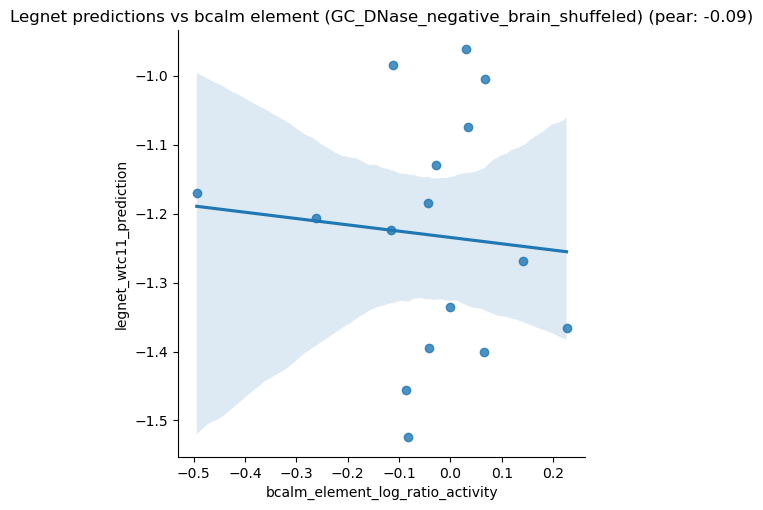

Pearson correlation coefficient: 0.15
P-value: 0.0000


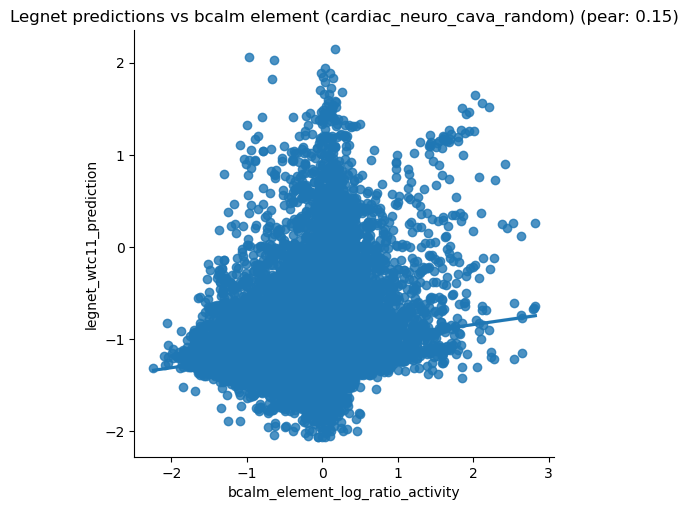

Pearson correlation coefficient: 0.21
P-value: 0.1466


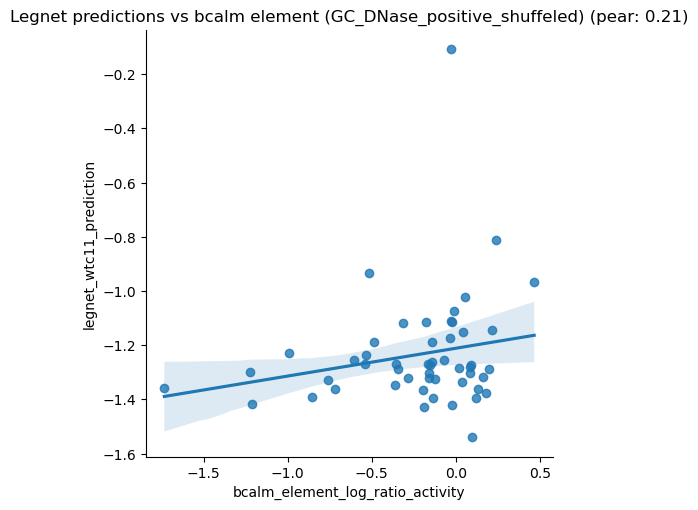

Pearson correlation coefficient: 0.07
P-value: 0.3507


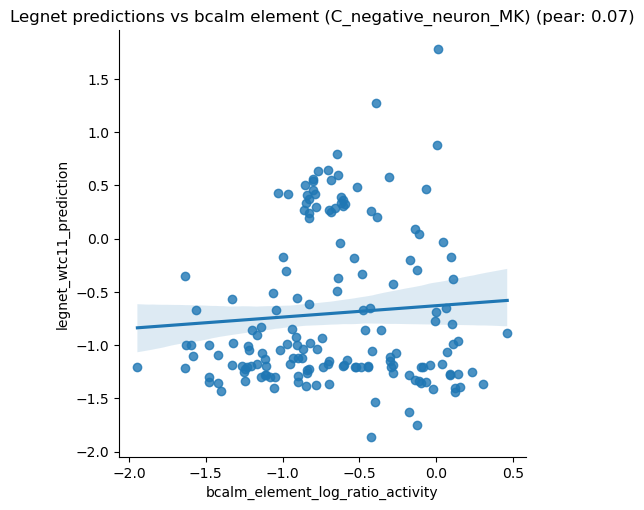

Pearson correlation coefficient: 0.17
P-value: 0.1580


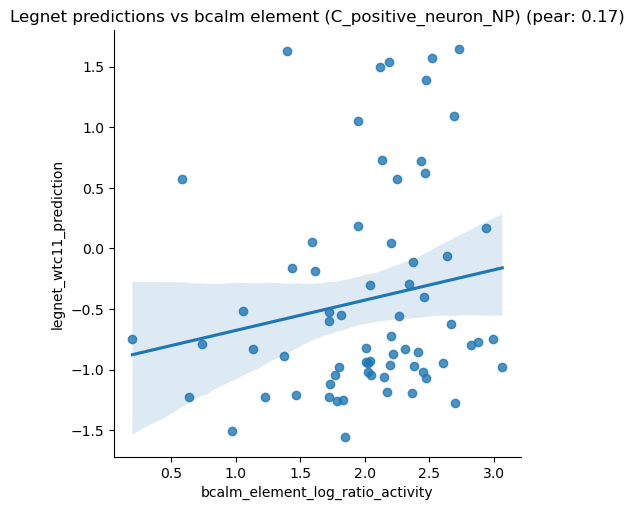

Pearson correlation coefficient: 0.21
P-value: 0.0529


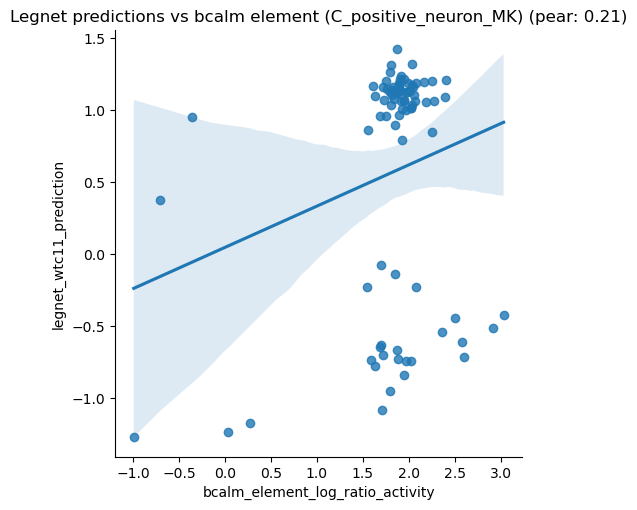

Pearson correlation coefficient: 0.06
P-value: 0.5753


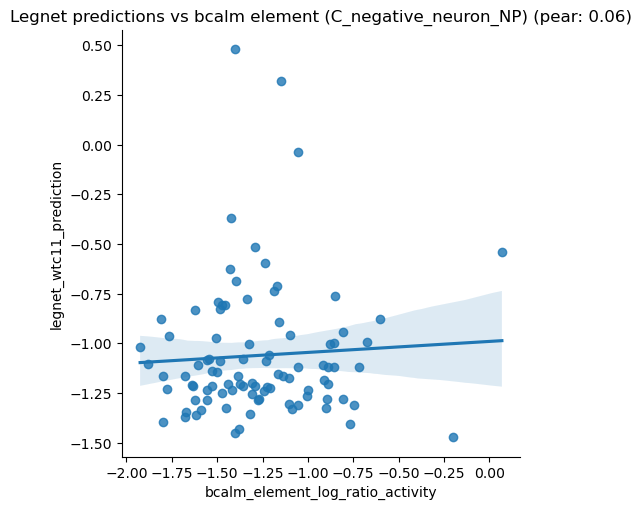

Pearson correlation coefficient: 0.59
P-value: 0.0000


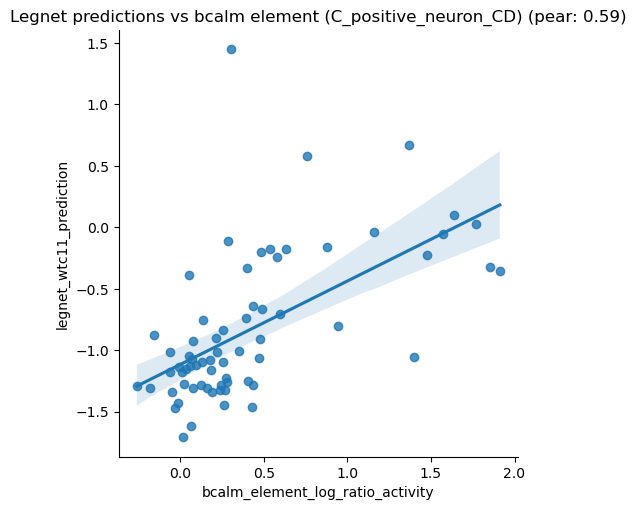

In [ ]:
# for each label
for label in testing_mpra80k_legnet_prediction["label"].unique():
    tested_mpra80k_legnet_prediction = testing_mpra80k_legnet_prediction.loc[testing_mpra80k_legnet_prediction['label'] == label]
    # Compute Pearson correlation
    corr_coef, p_value = pearsonr(tested_mpra80k_legnet_prediction['bcalm_element_log_ratio_activity'], tested_mpra80k_legnet_prediction['legnet_wtc11_prediction'])
    print(f'Pearson correlation coefficient: {corr_coef:.2f}')
    print(f'P-value: {p_value:.4f}')

    # Plot using seaborn
    sns.lmplot(x='bcalm_element_log_ratio_activity', y='legnet_wtc11_prediction', data=tested_mpra80k_legnet_prediction)
    plt.title(f'Legnet predictions vs bcalm element ({label}) (pear: {corr_coef:.2f})')

    plt.show()


### How is the correlation of WTC11 elements: 
- correlation of all regions
- correlation of all sequences with high activity
- correlation of all cCREs

In [139]:
tested_mpra80k_legnet_prediction.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor', 'open_E2G_neural_progenitor_H9',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized',
       'plotting_label_open_screen_neural_progenitor',
       'plotting_label_open_ngn2',
       'plotting_label_open_screen_H9_neural_progenitor',
       'plotting_open_regions_E2G_H9_neural_progenitor',
       'more_active_scrambled', 'more_active_negative_ctrl', 'DNase_max',
       'max_col', 'region_strand_id',
       'bcalm_element_adjusted_p_

Pearson correlation coefficient: 0.14
P-value: 0.0000


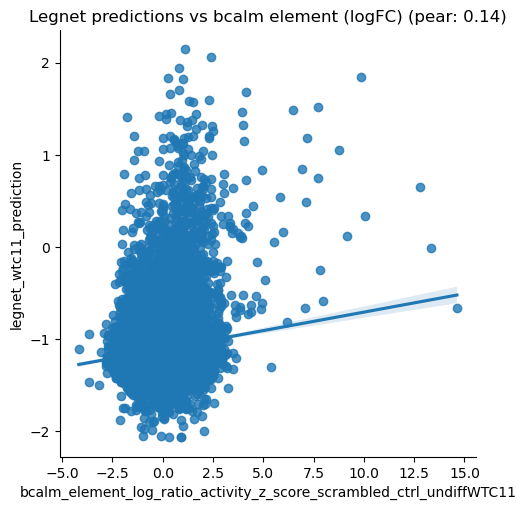

In [140]:
column_name_activity = "bcalm_element_log_ratio_activity_undiffWTC11"
column_name_activity = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl_undiffWTC11"
# Compute Pearson correlation
corr_coef, p_value = pearsonr(tested_mpra80k_legnet_prediction[column_name_activity], tested_mpra80k_legnet_prediction['legnet_wtc11_prediction'])
print(f'Pearson correlation coefficient: {corr_coef:.2f}')
print(f'P-value: {p_value:.4f}')

# Plot using seaborn
sns.lmplot(x=column_name_activity, y='legnet_wtc11_prediction', data=tested_mpra80k_legnet_prediction)
plt.title(f'Legnet predictions vs bcalm element (logFC) (pear: {corr_coef:.2f})')

plt.show()

# tested_mpra80k_legnet_prediction["more_active_scrambled"] = (tested_mpra80k_legnet_prediction["bcalm_element_adjusted_p_value"] < 0.1) & (tested_mpra80k_legnet_prediction["bcalm_element_log_ratio_activity"] > 0)

In [141]:
tested_mpra80k_legnet_prediction.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor', 'open_E2G_neural_progenitor_H9',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized',
       'plotting_label_open_screen_neural_progenitor',
       'plotting_label_open_ngn2',
       'plotting_label_open_screen_H9_neural_progenitor',
       'plotting_open_regions_E2G_H9_neural_progenitor',
       'more_active_scrambled', 'more_active_negative_ctrl', 'DNase_max',
       'max_col', 'region_strand_id',
       'bcalm_element_adjusted_p_

In [142]:
tested_mpra80k_legnet_prediction

,name,sequence,category,class,source,ref,chr,start,end,strand,...,DNase_max,max_col,region_strand_id,bcalm_element_adjusted_p_value_undiffWTC11,bcalm_element_log_ratio_activity_undiffWTC11,bcalm_data_exists_undiffWTC11,not_shifted_bcalm_element_log_ratio_activity_undiffWTC11,bcalm_element_log_ratio_activity_z_score_neg_ctrl_undiffWTC11,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl_undiffWTC11,legnet_wtc11_prediction
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,1.1717,DNASE:BE2C,chr1:2181843-2182113_+,1.0,-0.113830,True,-0.113830,-0.108557,-1.453587,-1.272144
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,0.4162,DNASE:spleen male adult (54 years),chr1:2182439-2182709_+,1.0,0.010062,True,0.010062,1.911857,0.618579,-1.321578
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,0.9793,DNASE:RPMI-7951,chr1:2188389-2188659_+,1.0,-0.005756,True,-0.005756,1.653895,0.354010,-0.990258
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636,2192906,+,...,0.3038,DNASE:spleen male adult (54 years),chr1:2192636-2192906_+,1.0,-0.024935,True,-0.024935,1.341123,0.033226,-1.179183
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380,2203650,+,...,0.6891,DNASE:RPMI8226,chr1:2203380-2203650_+,1.0,-0.152061,True,-0.152061,-0.732015,-2.093014,-1.465978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24215,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466,154519736,-,...,1.1088,DNASE:BE2C,chrX:154519466-154519736_-,1.0,-0.022539,True,-0.022539,1.380206,0.073310,-1.174137
24216,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,1.4407,DNASE:SK-MEL-5.1,chrX:154539055-154539325_-,1.0,0.021838,True,0.021838,2.103896,0.815538,-1.057012
24217,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,2.2879,DNASE:BE2C,chrX:154545000-154545270_-,1.0,0.081223,True,0.081223,3.072344,1.808792,-1.066687
24218,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,5.0170,DNASE:foreskin keratinocyte male newborn.1,chrX:154549802-154550072_-,1.0,-0.099619,True,-0.099619,0.123202,-1.215891,-1.446339


n: 138
Pearson correlation coefficient: 0.53
P-value: 0.0000


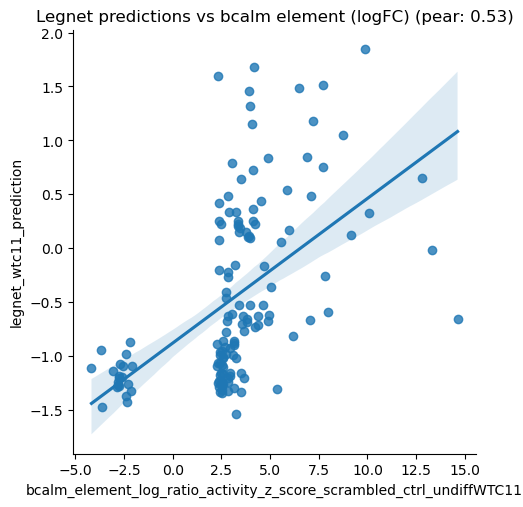

In [143]:
active_scrambled = tested_mpra80k_legnet_prediction.loc[(tested_mpra80k_legnet_prediction["bcalm_element_adjusted_p_value_undiffWTC11"]< 0.1)]
print(f"n: {active_scrambled.shape[0]}")
column_name_activity = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl_undiffWTC11"

# Compute Pearson correlation
corr_coef, p_value = pearsonr(active_scrambled[column_name_activity], active_scrambled['legnet_wtc11_prediction'])
print(f'Pearson correlation coefficient: {corr_coef:.2f}')
print(f'P-value: {p_value:.4f}')

# Plot using seaborn
sns.lmplot(x=column_name_activity, y='legnet_wtc11_prediction', data=active_scrambled)
plt.title(f'Legnet predictions vs bcalm element (logFC) (pear: {corr_coef:.2f})')

plt.show()

In [144]:
tested_mpra80k_legnet_prediction

,name,sequence,category,class,source,ref,chr,start,end,strand,...,DNase_max,max_col,region_strand_id,bcalm_element_adjusted_p_value_undiffWTC11,bcalm_element_log_ratio_activity_undiffWTC11,bcalm_data_exists_undiffWTC11,not_shifted_bcalm_element_log_ratio_activity_undiffWTC11,bcalm_element_log_ratio_activity_z_score_neg_ctrl_undiffWTC11,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl_undiffWTC11,legnet_wtc11_prediction
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,1.1717,DNASE:BE2C,chr1:2181843-2182113_+,1.0,-0.113830,True,-0.113830,-0.108557,-1.453587,-1.272144
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,0.4162,DNASE:spleen male adult (54 years),chr1:2182439-2182709_+,1.0,0.010062,True,0.010062,1.911857,0.618579,-1.321578
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,0.9793,DNASE:RPMI-7951,chr1:2188389-2188659_+,1.0,-0.005756,True,-0.005756,1.653895,0.354010,-0.990258
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636,2192906,+,...,0.3038,DNASE:spleen male adult (54 years),chr1:2192636-2192906_+,1.0,-0.024935,True,-0.024935,1.341123,0.033226,-1.179183
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380,2203650,+,...,0.6891,DNASE:RPMI8226,chr1:2203380-2203650_+,1.0,-0.152061,True,-0.152061,-0.732015,-2.093014,-1.465978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24215,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466,154519736,-,...,1.1088,DNASE:BE2C,chrX:154519466-154519736_-,1.0,-0.022539,True,-0.022539,1.380206,0.073310,-1.174137
24216,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,1.4407,DNASE:SK-MEL-5.1,chrX:154539055-154539325_-,1.0,0.021838,True,0.021838,2.103896,0.815538,-1.057012
24217,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,2.2879,DNASE:BE2C,chrX:154545000-154545270_-,1.0,0.081223,True,0.081223,3.072344,1.808792,-1.066687
24218,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,5.0170,DNASE:foreskin keratinocyte male newborn.1,chrX:154549802-154550072_-,1.0,-0.099619,True,-0.099619,0.123202,-1.215891,-1.446339


In [ ]:
# bed:
wtc11_ccres_path = "/home/kisa/coding/80K_MPRA/cCREs_overlap/SCREEN_tissue/WTC11_ENCFF736FHB_ENCFF857KTM_ENCFF306ZMK_cCRE_open_filtered.bed.gz"
wtc11_ccres = pd.read_csv(wtc11_ccres_path, sep="\t", header=None)
wtc11_ccres.columns = ["wtc11_ccre_chr", "wtc11_ccre_start", "wtc11_ccre_end", "SCREEN_ID", "wtc11_ccre_score", "wtc11_ccre_strand", "wtc11_ccre_info", "wtc11_ccre_info_II", "wtc11_ccre_values", "wtc11_ccre_annotation", "wtc11_ccre_info_III"]
wtc11_ccres_screen_ids = wtc11_ccres["SCREEN_ID"].to_list()

In [146]:
wtc11_ccres

,wtc11_ccre_chr,wtc11_ccre_start,wtc11_ccre_end,SCREEN_ID,wtc11_ccre_score,wtc11_ccre_strand,wtc11_ccre_info,wtc11_ccre_info_II,wtc11_ccre_values,wtc11_ccre_annotation,wtc11_ccre_info_III
0,chr1,778570,778919,EH38E2776539,0,.,778570,778919,"255,0,0",PLS,Missing-data/Partial-classification
1,chr1,779023,779182,EH38E3951314,0,.,779023,779182,"255,0,0",PLS,Missing-data/Partial-classification
2,chr1,827417,827767,EH38E2776555,0,.,827417,827767,"255,0,0",PLS,Missing-data/Partial-classification
3,chr1,904578,904918,EH38E2776597,0,.,904578,904918,"255,0,0",PLS,Missing-data/Partial-classification
4,chr1,923719,924069,EH38E2776639,0,.,923719,924069,"255,0,0",PLS,Missing-data/Partial-classification
...,...,...,...,...,...,...,...,...,...,...,...
41930,chrY,19076954,19077299,EH38E3951015,0,.,19076954,19077299,"255,0,0",PLS,Missing-data/Partial-classification
41931,chrY,19077412,19077756,EH38E3951016,0,.,19077412,19077756,"255,0,0",PLS,Missing-data/Partial-classification
41932,chrY,19567038,19567384,EH38E3951052,0,.,19567038,19567384,"255,0,0",PLS,Missing-data/Partial-classification
41933,chrY,19744631,19744981,EH38E3951072,0,.,19744631,19744981,"255,0,0",PLS,Missing-data/Partial-classification


In [147]:
wtc11_ccres_screen_ids = wtc11_ccres["SCREEN_ID"].to_list()

In [148]:
import re

def extract_eh38e_number(header):
    # Use regex to find the pattern that starts with EH38E followed by digits
    match = re.search(r"EH38E\d+", header)
    if match:
        return match.group(0)  # Return the matched string
    return None  # Return None if no match is found


In [149]:
tested_mpra80k_legnet_prediction
tested_mpra80k_legnet_prediction['SCREEN_ID'] = tested_mpra80k_legnet_prediction[col_name].apply(extract_eh38e_number)

In [150]:
tested_mpra80k_legnet_prediction_output = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/undiffWTC11_legnet_prediction_metadata_zscore.tsv.gz"
tested_mpra80k_legnet_prediction.to_csv(tested_mpra80k_legnet_prediction_output, sep="\t", index=False)

In [151]:
tested_mpra80k_legnet_prediction_wtc11_ccres = tested_mpra80k_legnet_prediction.merge(wtc11_ccres, on="SCREEN_ID", how="inner")

In [152]:
tested_mpra80k_legnet_prediction_wtc11_ccres

,name,sequence,category,class,source,ref,chr,start,end,strand,...,wtc11_ccre_chr,wtc11_ccre_start,wtc11_ccre_end,wtc11_ccre_score,wtc11_ccre_strand,wtc11_ccre_info,wtc11_ccre_info_II,wtc11_ccre_values,wtc11_ccre_annotation,wtc11_ccre_info_III
0,cardiac_neuro_cava_random:ST3GAL3|ENSG00000126...,TGGACGGAAGCCCCTGGATTCTGTTCCAGGCATAGCCTGAGGTTAG...,element,test,NaN,GRCh38,chr1,43885622,43885892,+,...,chr1,43885668,43885847,0,.,43885668,43885847,"255,205,0",dELS,Missing-data/Partial-classification
1,cardiac_neuro_cava_random:NOS1AP|ENSG000001989...,GACGCAACTTTTCTCTTTTTCCTCCCCTCCCCCAGAGTATTTAGTA...,element,test,NaN,GRCh38,chr1,162145422,162145692,+,...,chr1,162145382,162145732,0,.,162145382,162145732,"255,205,0",dELS,Missing-data/Partial-classification
2,cardiac_neuro_cava_random:RERE|ENSG00000142599...,GCATAACAAATTTAGTTCAGTTTCAGGTTAGAGATTGGTGTGGATT...,element,test,NaN,GRCh38,chr1,8789661,8789931,-,...,chr1,8789670,8789923,0,.,8789670,8789923,"255,205,0",dELS,Missing-data/Partial-classification
3,cardiac_neuro_cava_random:LEFTY2|ENSG000001437...,GAGTCAGGGTAGGGATCACTCATTCCCTTGCCCCGCTCTCCTCCCT...,element,test,NaN,GRCh38,chr1,225890301,225890571,-,...,chr1,225890331,225890542,0,.,225890331,225890542,"255,167,0",pELS,Missing-data/Partial-classification
4,cardiac_neuro_cava_random:LEFTY2|ENSG000001437...,CACTTGGTATAGAGGAGAAAAGAGAAGCAGGCTCTTTTCTTGACCT...,element,test,NaN,GRCh38,chr1,225899594,225899864,-,...,chr1,225899648,225899810,0,.,225899648,225899810,"255,205,0",dELS,Missing-data/Partial-classification
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,cardiac_neuro_cava_random:REF_NLGN3|ENSG000001...,GACATGGAGGAGGGTGGGGGAATTTCACCCCGGGGAGGTGGTGGAG...,variant,test,NaN,GRCh38,chrX,71103625,71103895,+,...,chrX,71103585,71103935,0,.,71103585,71103935,"255,205,0",dELS,Missing-data/Partial-classification
150,cardiac_neuro_cava_random:REF_NLGN3|ENSG000001...,CAATTTCCGTACAGGAAAGAGGAGGTTCATTTCCTTATAAGGAGCT...,variant,test,NaN,GRCh38,chrX,71182443,71182713,+,...,chrX,71182472,71182685,0,.,71182472,71182685,"255,205,0",dELS,Missing-data/Partial-classification
151,cardiac_neuro_cava_random:REF_ZIC3|ENSG0000015...,TTTAAACTCCCTTGTTATTCCTCAGTTCTGGGCGCCTCGCGGGGGA...,variant,test,NaN,GRCh38,chrX,137574832,137575102,+,...,chrX,137574867,137575068,0,.,137574867,137575068,"255,167,0",pELS,Missing-data/Partial-classification
152,cardiac_neuro_cava_random:REF_ZIC3|ENSG0000015...,CTTCGTGGAGACCAACGGCCAAACGGAAAAGTCAGCCCTCTTGGGG...,variant,test,NaN,GRCh38,chrX,137575620,137575890,+,...,chrX,137575651,137575859,0,.,137575651,137575859,"255,167,0",pELS,Missing-data/Partial-classification


In [153]:
tested_mpra80k_legnet_prediction

,name,sequence,category,class,source,ref,chr,start,end,strand,...,max_col,region_strand_id,bcalm_element_adjusted_p_value_undiffWTC11,bcalm_element_log_ratio_activity_undiffWTC11,bcalm_data_exists_undiffWTC11,not_shifted_bcalm_element_log_ratio_activity_undiffWTC11,bcalm_element_log_ratio_activity_z_score_neg_ctrl_undiffWTC11,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl_undiffWTC11,legnet_wtc11_prediction,SCREEN_ID
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,DNASE:BE2C,chr1:2181843-2182113_+,1.0,-0.113830,True,-0.113830,-0.108557,-1.453587,-1.272144,EH38E2778476
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,DNASE:spleen male adult (54 years),chr1:2182439-2182709_+,1.0,0.010062,True,0.010062,1.911857,0.618579,-1.321578,EH38E2778477
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,DNASE:RPMI-7951,chr1:2188389-2188659_+,1.0,-0.005756,True,-0.005756,1.653895,0.354010,-0.990258,EH38E2778484
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636,2192906,+,...,DNASE:spleen male adult (54 years),chr1:2192636-2192906_+,1.0,-0.024935,True,-0.024935,1.341123,0.033226,-1.179183,EH38E2778493
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380,2203650,+,...,DNASE:RPMI8226,chr1:2203380-2203650_+,1.0,-0.152061,True,-0.152061,-0.732015,-2.093014,-1.465978,EH38E2778514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24215,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466,154519736,-,...,DNASE:BE2C,chrX:154519466-154519736_-,1.0,-0.022539,True,-0.022539,1.380206,0.073310,-1.174137,EH38E2774366
24216,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,DNASE:SK-MEL-5.1,chrX:154539055-154539325_-,1.0,0.021838,True,0.021838,2.103896,0.815538,-1.057012,EH38E3949725
24217,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,DNASE:BE2C,chrX:154545000-154545270_-,1.0,0.081223,True,0.081223,3.072344,1.808792,-1.066687,EH38E3949733
24218,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,DNASE:foreskin keratinocyte male newborn.1,chrX:154549802-154550072_-,1.0,-0.099619,True,-0.099619,0.123202,-1.215891,-1.446339,EH38E2774396


In [154]:
tested_mpra80k_legnet_prediction['WTC11_cCRE'] = tested_mpra80k_legnet_prediction["SCREEN_ID"].isin(wtc11_ccres_screen_ids)

In [155]:
tested_mpra80k_legnet_prediction["WTC11_cCRE"]

0        False
1        False
2        False
3        False
4        False
         ...  
24215    False
24216    False
24217    False
24218    False
24219    False
Name: WTC11_cCRE, Length: 24220, dtype: bool

Pearson correlation coefficient: 0.49
P-value: 0.0000


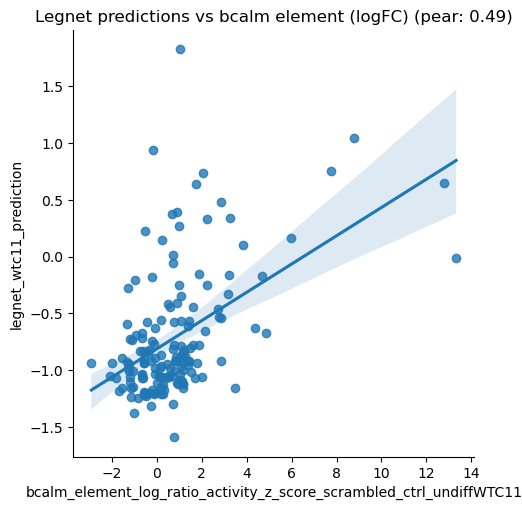

In [156]:
# wtc11_cCREs_bcalm = tested_mpra80k_legnet_prediction.loc[tested_mpra80k_legnet_prediction["WTC11_cCRE"]].copy()

column_name_activity = "bcalm_element_log_ratio_activity_undiffWTC11"
column_name_activity = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl_undiffWTC11"

# Compute Pearson correlation
corr_coef, p_value = pearsonr(tested_mpra80k_legnet_prediction_wtc11_ccres[column_name_activity], tested_mpra80k_legnet_prediction_wtc11_ccres['legnet_wtc11_prediction'])
print(f'Pearson correlation coefficient: {corr_coef:.2f}')
print(f'P-value: {p_value:.4f}')

# Plot using seaborn
sns.lmplot(x=column_name_activity, y='legnet_wtc11_prediction', data=tested_mpra80k_legnet_prediction_wtc11_ccres)
plt.title(f'Legnet predictions vs bcalm element (logFC) (pear: {corr_coef:.2f})')

plt.show()

# tested_mpra80k_legnet_prediction["more_active_scrambled"] = (tested_mpra80k_legnet_prediction["bcalm_element_adjusted_p_value"] < 0.1) & (tested_mpra80k_legnet_prediction["bcalm_element_log_ratio_activity"] > 0)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

dataframe_prediction_measurments
annotations_for_coloring = 'wtc11_ccre_annotation'
# column name of the real value you would like to correlate against the predictions
column_name_activity = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl_undiffWTC11"
column_prediction = 'legnet_wtc11_prediction'

# Compute Pearson correlation
corr_coef, p_value = pearsonr(dataframe_prediction_measurments[column_name_activity], dataframe_prediction_measurments[column_prediction])
print(f'Pearson correlation coefficient: {corr_coef:.2f}')
print(f'P-value: {p_value}')

# Create the scatter plot colored by annotation
sns.scatterplot(
    x=column_name_activity,
    y=column_prediction,
    data=dataframe_prediction_measurments,
    # hue=annotations_for_coloring,
    palette='Set2',
    alpha=0.7
)

# Add the regression (correlation) line
sns.regplot(
    x=column_name_activity,
    y=column_prediction,
    data=dataframe_prediction_measurments,
    scatter=False,  # don't plot points again
    color='black',  # correlation line color
    line_kws={'linewidth': 2}
)

plt.title(f'Legnet predictions vs bcalm element (logFC)\nPearson r: {corr_coef:.2f}, p: {p_value:.4f}')
plt.show()

Pearson correlation coefficient: 0.49
P-value: 8.26820837081215e-11


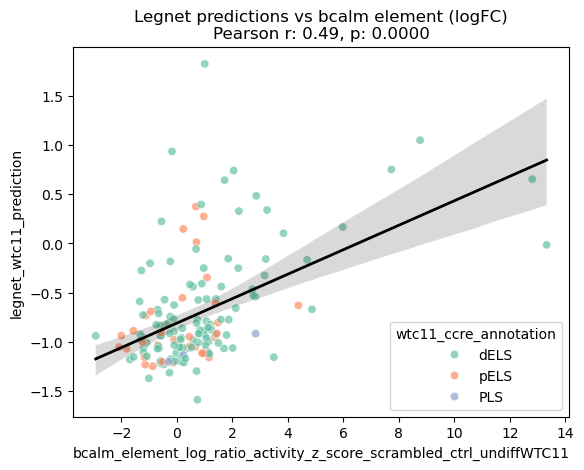

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
# wtc11_cCREs_bcalm = tested_mpra80k_legnet_prediction.loc[tested_mpra80k_legnet_prediction["WTC11_cCRE"]].copy()

column_name_activity = "bcalm_element_log_ratio_activity_undiffWTC11"
column_name_activity = "bcalm_element_log_ratio_activity_z_score_scrambled_ctrl_undiffWTC11"

# Compute Pearson correlation
corr_coef, p_value = pearsonr(tested_mpra80k_legnet_prediction_wtc11_ccres[column_name_activity], tested_mpra80k_legnet_prediction_wtc11_ccres['legnet_wtc11_prediction'])
print(f'Pearson correlation coefficient: {corr_coef:.2f}')
print(f'P-value: {p_value}')

# Create the scatter plot colored by annotation
sns.scatterplot(
    x=column_name_activity,
    y='legnet_wtc11_prediction',
    data=tested_mpra80k_legnet_prediction_wtc11_ccres,
    hue='wtc11_ccre_annotation',
    palette='Set2',
    alpha=0.7
)

# Add the regression (correlation) line
sns.regplot(
    x=column_name_activity,
    y='legnet_wtc11_prediction',
    data=tested_mpra80k_legnet_prediction_wtc11_ccres,
    scatter=False,  # don't plot points again
    color='black',  # correlation line color
    line_kws={'linewidth': 2}
)

plt.title(f'Legnet predictions vs bcalm element (logFC)\nPearson r: {corr_coef:.2f}, p: {p_value:.4f}')
plt.show()

In [ ]:
wtc11_ccres_path

#### What about significant variants between ngn2 and undiff WTC11

In [ ]:
WTC11_variants_metadata_bcalm_2025_bbmap_scrambled

In [1]:
import pandas as pd

In [ ]:
undiffWTC11_variant_info_path = "/home/kisa/coding/80K_MPRA/bc_MPRAlm_results/results/testing_undiffWTC11_variant_bcalm_80k_bbmap_no_outlier_removal_normalized_counts_2025_05_mpralib_design_variant_map_unique_id_all_rep_DNA_RNA.tsv"
undiffWTC11_variant_info = pd.read_csv(undiffWTC11_variant_info_path, sep="\t")
undiffWTC11_variant_info.rename(columns={'logFC': 'undiffWTC11_logFC', 'adj.P.Val': 'undiffWTC11_adjP'}, inplace=True)
undiffWTC11_variant_info_sig = undiffWTC11_variant_info.loc[undiffWTC11_variant_info["undiffWTC11_adjP"] < 0.1].copy()
undiffWTC11_variant_info_significant_set = set(undiffWTC11_variant_info_sig['variant_id'].to_list())

# undiffWTC11_variant_info_sig

In [7]:
NGN2_variant_info_path = "/home/kisa/coding/80K_MPRA/bc_MPRAlm_results/results/NGN2_variant_bcalm_80k_bbmap_selfmadeStrandSensitive_no_outlier_removal_normalized_counts_removed_additional_normalization_2025_05_mpralib_design_variant_map_unique_id_all_rep_DNA_RNA.tsv"
NGN2_variant_info = pd.read_csv(NGN2_variant_info_path, sep="\t")
NGN2_variant_info_sig = NGN2_variant_info.loc[NGN2_variant_info["adj.P.Val"] < 0.1].copy()
NGN2_variant_info_significant_set = set(NGN2_variant_info_sig['variant_id'].to_list())
NGN2_variant_info_sig

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id
0,0.575834,0.515537,27.966666,3.351799e-114,1.323893e-109,248.543368,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...
1,-0.349480,0.262414,-20.413525,2.688349e-71,5.309221e-67,150.982424,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...
2,0.214057,0.192010,17.753706,1.632040e-60,2.010300e-56,126.799722,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...
3,0.345477,0.208888,19.005451,2.035850e-60,2.010300e-56,126.038838,cardiac_neuro_cava_random:ALT_TRIO|ENSG0000003...
4,0.382245,0.212891,18.576390,1.800017e-55,1.421942e-51,114.508350,cardiac_neuro_cava_random:ALT_ANKZF1|ENSG00000...
...,...,...,...,...,...,...,...
1400,0.023555,-0.019790,3.017994,2.620706e-03,8.993279e-02,-2.664472,cardiac_neuro_cava_random:ALT_DSG2|ENSG0000004...
1437,-0.028539,0.041386,-2.975830,3.018020e-03,9.910516e-02,-2.722402,cardiac_neuro_cava_random:ALT_ST3GAL3|ENSG0000...
1467,-0.024732,-0.001222,-2.991657,2.852051e-03,9.546638e-02,-2.760639,cardiac_neuro_cava_random:ALT_CACNA1C|ENSG0000...
1485,-0.023001,0.009591,-2.982958,2.933534e-03,9.754664e-02,-2.786958,cardiac_neuro_cava_random:ALT_FOXP1|ENSG000001...


In [14]:
ngn2_undiffWTC11_variants = NGN2_variant_info.merge(undiffWTC11_variant_info[['variant_id', 'undiffWTC11_logFC', 'undiffWTC11_adjP']], on='variant_id', how="inner")

In [15]:
sig_level = 0.1
ngn2_undiffWTC11_variants['is_ngn2_significant'] = ngn2_undiffWTC11_variants['adj.P.Val'] < sig_level
ngn2_undiffWTC11_variants['is_undiffWTC11_significant'] = ngn2_undiffWTC11_variants['undiffWTC11_adjP'] < sig_level


In [17]:
ngn2_undiffWTC11_variants.loc[(ngn2_undiffWTC11_variants['is_ngn2_significant']) & (ngn2_undiffWTC11_variants['is_undiffWTC11_significant'])].shape[0]

32

In [19]:
ngn2_undiffWTC11_variants.loc[(ngn2_undiffWTC11_variants['is_ngn2_significant']) & (ngn2_undiffWTC11_variants['is_undiffWTC11_significant'])].shape[0]/ngn2_undiffWTC11_variants['is_undiffWTC11_significant'].sum()

0.36363636363636365

In [9]:
undiffWTC11_variant_info_significant_set - NGN2_variant_info_significant_set

{'GC_Liang:ALT_rs1036014|Liang_fwd_tile1-1_rs1036014',
 'cardiac_neuro_cava_random:ALT_ARHGAP31|ENSG00000031081.11|EH38E2230631_fwd_tile1-1_ARHGAP31|ENSG00000031081.11|EH38E2230631|3-119365581-A-T',
 'cardiac_neuro_cava_random:ALT_AUTS2|ENSG00000158321.19|EH38E3778203_fwd_tile1-1_AUTS2|ENSG00000158321.19|EH38E3778203|7-69953529-T-C',
 'cardiac_neuro_cava_random:ALT_BARD1|ENSG00000138376.11|EH38E3398390_rev_tile1-1_BARD1|ENSG00000138376.11|EH38E3398390|2-214791444-C-G',
 'cardiac_neuro_cava_random:ALT_CASQ2|ENSG00000118729.12|EH38E1378994_rev_tile1-1_CASQ2|ENSG00000118729.12|EH38E1378994|1-115728446-T-C',
 'cardiac_neuro_cava_random:ALT_CDH2|ENSG00000170558.10|EH38E3261842_rev_tile1-1_CDH2|ENSG00000170558.10|EH38E3261842|18-28088604-T-C',
 'cardiac_neuro_cava_random:ALT_CELF2|ENSG00000048740.19|EH38E1447533_fwd_tile1-1_CELF2|ENSG00000048740.19|EH38E1447533|10-10872242-G-T',
 'cardiac_neuro_cava_random:ALT_CUX1|ENSG00000257923.12|EH38E2576734_fwd_tile1-1_CUX1|ENSG00000257923.12|EH38E2576

### Try to annotate the open chromatin information in the correlation plot:
- 

,chr,start,end,SCREEN_ID,score,strand
0,chr1,2179468,2179817,EH38E2778471,.,+
1,chr1,3036655,3036981,EH38E1312297,.,+
2,chr1,3037151,3037369,EH38E2779534,.,+
3,chr1,3125761,3126100,EH38E2779650,.,+
4,chr1,3125761,3126100,EH38E2779650,.,+
...,...,...,...,...,...,...
683,chrX,71182472,71182685,EH38E3937073,.,+
684,chrX,135974275,135974557,EH38E3946102,.,+
685,chrX,135974275,135974557,EH38E3946102,.,+
686,chrX,135974275,135974557,EH38E3946102,.,+
